## Load Data
Pada eksperimen training 16 arsitektur, kami menjalankan notebook ini di Collab agar bisa memanfaatkan GPU yang ada. Dataset di-download dan di ekstrak di lokal. Karena keterbatasan push data besar ke github, maka dataset tidak di push ke repository dan dapat diakses melalui kaggle https://www.kaggle.com/datasets/puneet6060/intel-image-classification.  

In [3]:
!pip install tensorflow scikit-learn matplotlib seaborn kaggle


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install gdown


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score

import os
import gdown
import zipfile

In [2]:
url = "https://drive.google.com/file/d/19csBcImwszU2Ly0acoDPNB9Kj0_HOAFM/view?usp=drive_link"

base_dir = "../../data/cnn_data"
zip_path = os.path.join(base_dir, "dataset.zip")

train_dir = os.path.join(base_dir, "seg_train")
test_dir = os.path.join(base_dir, "seg_test")

os.makedirs(base_dir, exist_ok=True)

if not os.path.exists(zip_path):
    print("Dataset zip belum ada, downloading.")
    
    gdown.download(url, zip_path, quiet=False)

else:
    print("Dataset zip sudah ada, skip download.")


if not (os.path.exists(train_dir) and os.path.exists(test_dir)):
    print("Folder dataset belum ada, extracting zip.")

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(base_dir)

else:
    print("Folder dataset sudah ada, skip extract.")


train_dir = "../../data/cnn_data/seg_train/seg_train"
test_dir = "../../data/cnn_data/seg_test/seg_test"

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

print("Load Data Training:")
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int' 
)

print("\nLoad Data Testing:")
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False 
)

y_true = np.concatenate([y for x, y in test_ds], axis=0)
print(f"\nJumlah label test: {y_true.shape[0]}")

Dataset zip belum ada, downloading.


Downloading...
From (original): https://drive.google.com/uc?id=19csBcImwszU2Ly0acoDPNB9Kj0_HOAFM
From (redirected): https://drive.google.com/uc?id=19csBcImwszU2Ly0acoDPNB9Kj0_HOAFM&confirm=t&uuid=9b049808-12d6-422f-ab68-6f2aaf539d12
To: c:\Users\diyah\Tubes2_IF3270_Kelompok9\data\cnn_data\dataset.zip
100%|██████████| 363M/363M [00:33<00:00, 11.0MB/s] 


Folder dataset sudah ada, skip extract.
Load Data Training:
Found 14034 files belonging to 6 classes.

Load Data Testing:
Found 3000 files belonging to 6 classes.

Jumlah label test: 3000


## EDA

           Train  Test  Total
buildings   2191   437   2628
forest      2271   474   2745
glacier     2404   553   2957
mountain    2512   525   3037
sea         2274   510   2784
street      2382   501   2883


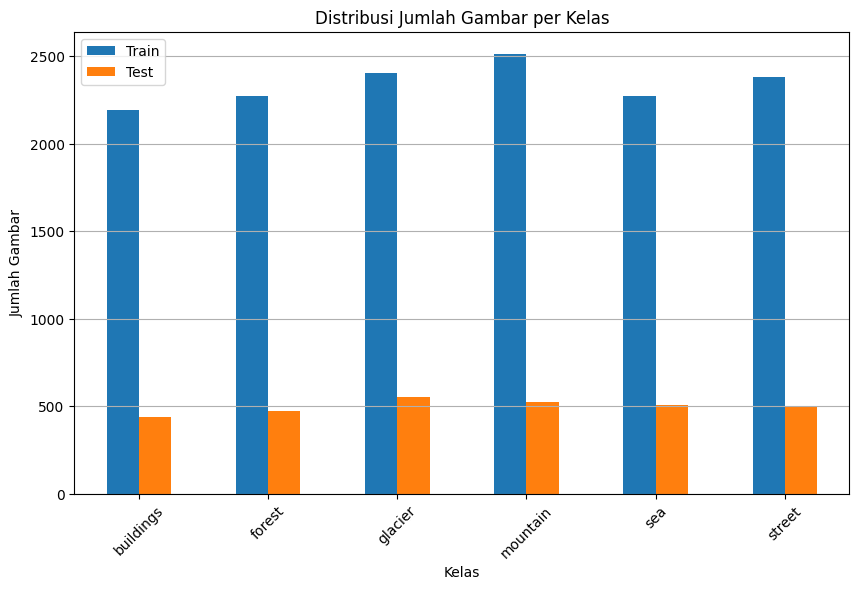

In [6]:
import pandas as pd

train_counts = {}
test_counts = {}

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        train_counts[class_name] = len(os.listdir(class_path))

for class_name in os.listdir(test_dir):
    class_path = os.path.join(test_dir, class_name)

    if os.path.isdir(class_path):
        test_counts[class_name] = len(os.listdir(class_path))

df_dist = pd.DataFrame({
    "Train": pd.Series(train_counts),
    "Test": pd.Series(test_counts)
})

df_dist["Total"] = df_dist["Train"] + df_dist["Test"]

print(df_dist)

ax = df_dist[["Train", "Test"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Distribusi Jumlah Gambar per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

### Analisis
Hasil histogram distribusi kelas menunjukkan bahwa distribusi kelas sudah cukup balance, tidak ada yang terlalu mendominasi. Hal ini menandakan tidak adanya resiko terjadi bias saat proses pembelajaran. 

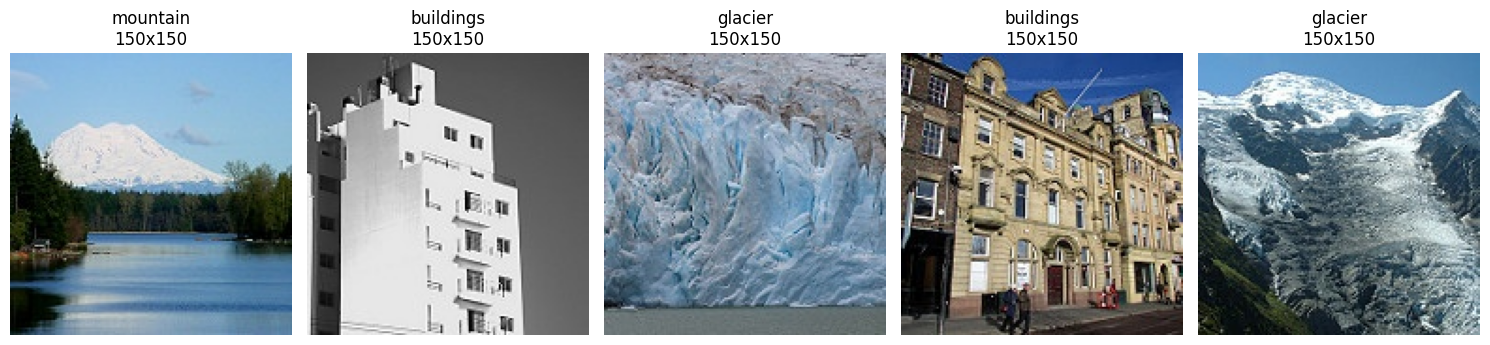

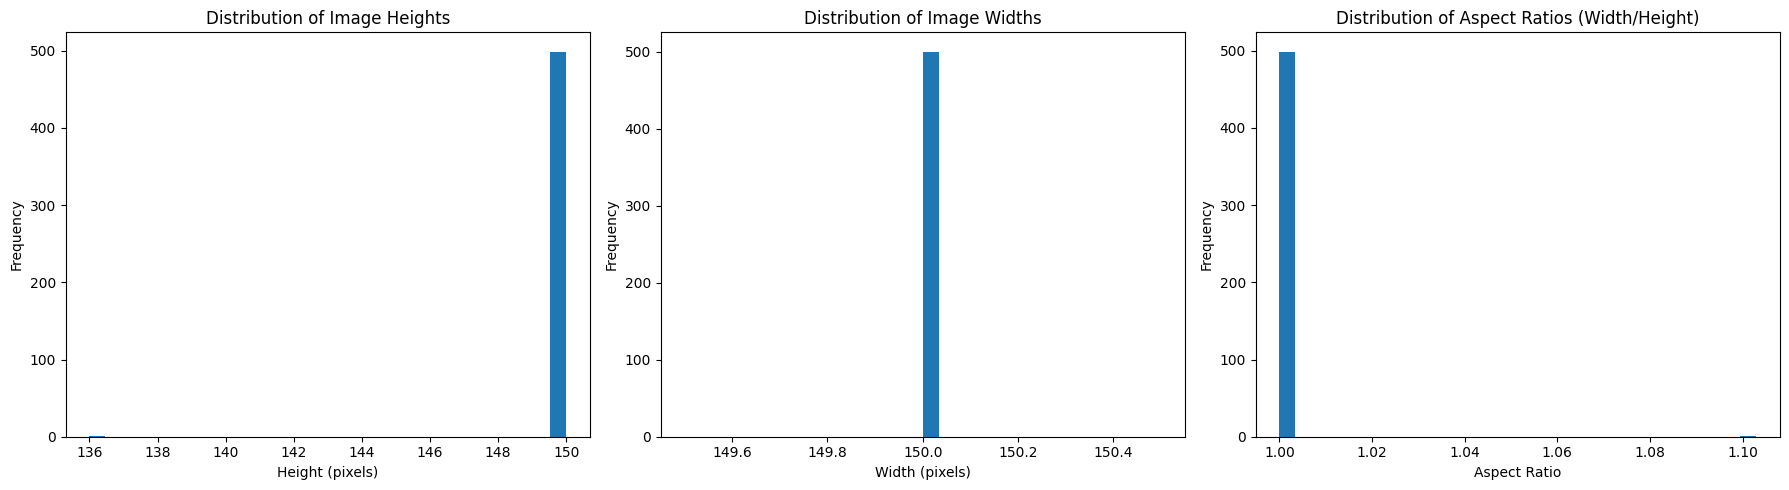


Height statistics (pixels):
mean: 149.97
median: 150.00
min: 136.00
max: 150.00
std: 0.63

Width statistics (pixels):
mean: 150.00
median: 150.00
min: 150.00
max: 150.00
std: 0.00


In [11]:
import random
from PIL import Image

image_paths = []
labels = []

for class_name in os.listdir(train_dir):

    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):

        for file_name in os.listdir(class_path):

            image_paths.append(os.path.join(class_path, file_name))
            labels.append(class_name)

random_idx = random.sample(range(len(image_paths)), 5)

plt.figure(figsize=(15, 10))

dimensions = []
aspect_ratios = []

for i, idx in enumerate(random_idx):
    img_path = image_paths[idx]
    label = labels[idx]

    img = Image.open(img_path)

    w, h = img.size

    dimensions.append((h, w))
    aspect_ratios.append(w / h)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(f"{label}\n{h}x{w}")
    plt.axis("off")

plt.tight_layout()
plt.show()

sample_size = min(500, len(image_paths))
sample_idx = random.sample(range(len(image_paths)), sample_size)

heights = []
widths = []
aspect_ratios = []

for idx in sample_idx:
    try:
        img = Image.open(image_paths[idx])
        w, h = img.size
        heights.append(h)
        widths.append(w)
        aspect_ratios.append(w / h)

    except Exception as e:
        print(f"Error processing {image_paths[idx]}: {e}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Height
axes[0].hist(heights, bins=30)
axes[0].set_title('Distribution of Image Heights')
axes[0].set_xlabel('Height (pixels)')
axes[0].set_ylabel('Frequency')

# Width
axes[1].hist(widths, bins=30)
axes[1].set_title('Distribution of Image Widths')
axes[1].set_xlabel('Width (pixels)')
axes[1].set_ylabel('Frequency')

# Aspect Ratio
axes[2].hist(aspect_ratios, bins=30)
axes[2].set_title('Distribution of Aspect Ratios (Width/Height)')
axes[2].set_xlabel('Aspect Ratio')
axes[2].set_ylabel('Frequency')

plt.tight_layout()

plt.show()

height_stats = {
    'mean': np.mean(heights),
    'median': np.median(heights),
    'min': np.min(heights),
    'max': np.max(heights),
    'std': np.std(heights)
}

width_stats = {
    'mean': np.mean(widths),
    'median': np.median(widths),
    'min': np.min(widths),
    'max': np.max(widths),
    'std': np.std(widths)
}

print("\nHeight statistics (pixels):")

for key, value in height_stats.items():
    print(f"{key}: {value:.2f}")

print("\nWidth statistics (pixels):")

for key, value in width_stats.items():
    print(f"{key}: {value:.2f}")

### Analisis
Berdasarkan hasil eksplorasi data, mayoritas gambar memiliki dimensi yang seragam yaitu sekitar 150×150 piksel dengan aspect ratio mendekati 1:1. Hal ini menunjukkan bahwa dataset telah melalui proses standarisasi ukuran sehingga tidak diperlukan preprocessing tambahan terkait resizing atau penyesuaian aspect ratio. Namun, preprocessing dasar seperti normalisasi nilai piksel dan data augmentation tetap dilakukan untuk meningkatkan performa dan generalisasi model CNN.

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


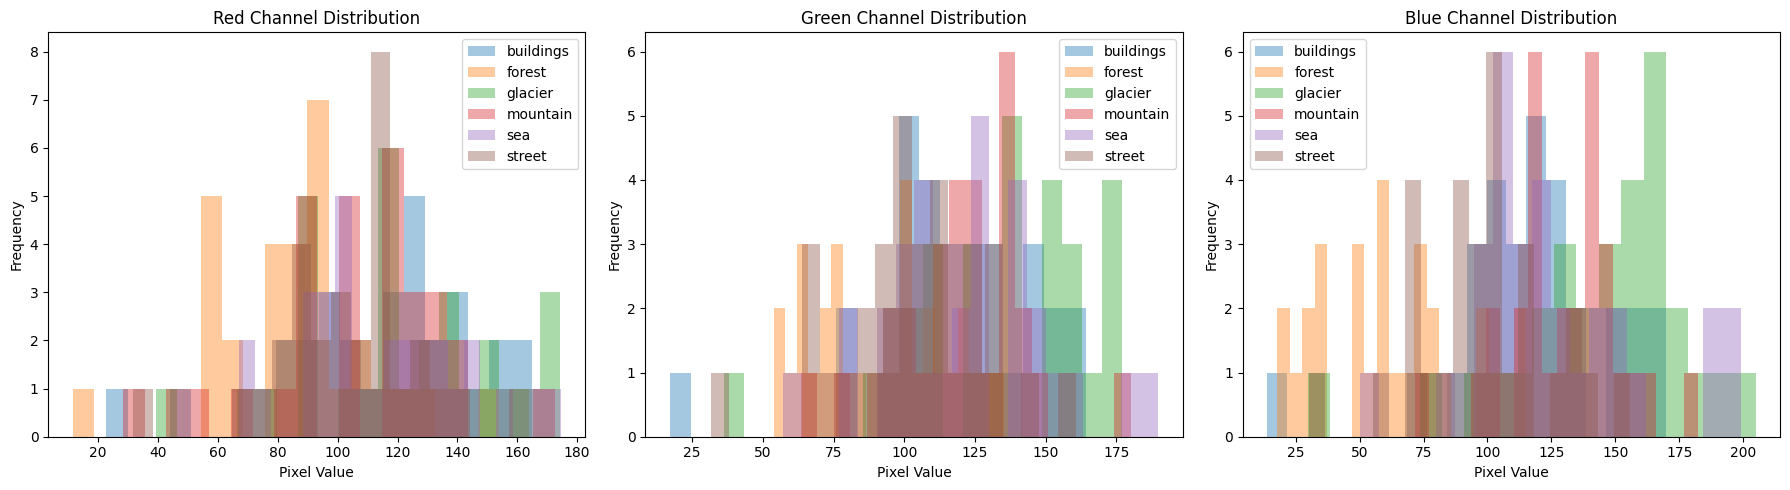

In [13]:
classes = sorted([
    folder for folder in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, folder))
])

print("Classes:", classes)

def get_avg_rgb(img_path):
    img = Image.open(img_path).convert("RGB")
    img_array = np.array(img)
    avg_color = img_array.mean(axis=(0, 1))

    return avg_color

rgb_data = {}

sample_per_class = 30

for class_name in classes:
    class_dir = os.path.join(train_dir, class_name)
    image_files = os.listdir(class_dir)
    sample_size = min(sample_per_class, len(image_files))
    sampled_images = random.sample(image_files, sample_size)
    rgb_values = []

    for file_name in sampled_images:

        try:
            img_path = os.path.join(class_dir, file_name)
            rgb_values.append(get_avg_rgb(img_path))

        except Exception as e:
            print(f"Error processing {img_path}: {e}")

    rgb_data[class_name] = np.array(rgb_values)


channels = ['Red', 'Green', 'Blue']

plt.figure(figsize=(18, 5))

for i, channel in enumerate(channels):

    plt.subplot(1, 3, i + 1)

    for class_name in classes:

        plt.hist(
            rgb_data[class_name][:, i],
            bins=20,
            alpha=0.4,
            label=class_name
        )

    plt.title(f'{channel} Channel Distribution')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.legend()

plt.tight_layout()

plt.show()

### Analisis
Distribusi kanal RGB menunjukkan bahwa setiap kelas memiliki karakteristik warna yang berbeda. Kelas forest cenderung memiliki intensitas kanal hijau yang lebih tinggi, sedangkan kelas sea memiliki dominasi kanal biru. Kelas glacier menunjukkan intensitas tinggi pada seluruh kanal akibat dominasi warna terang seperti putih dan abu-abu. Perbedaan distribusi warna ini menunjukkan bahwa informasi warna dapat menjadi feature penting yang dipelajari oleh model CNN dalam proses klasifikasi gambar.

Shape before PCA/t-SNE: (180, 4096)


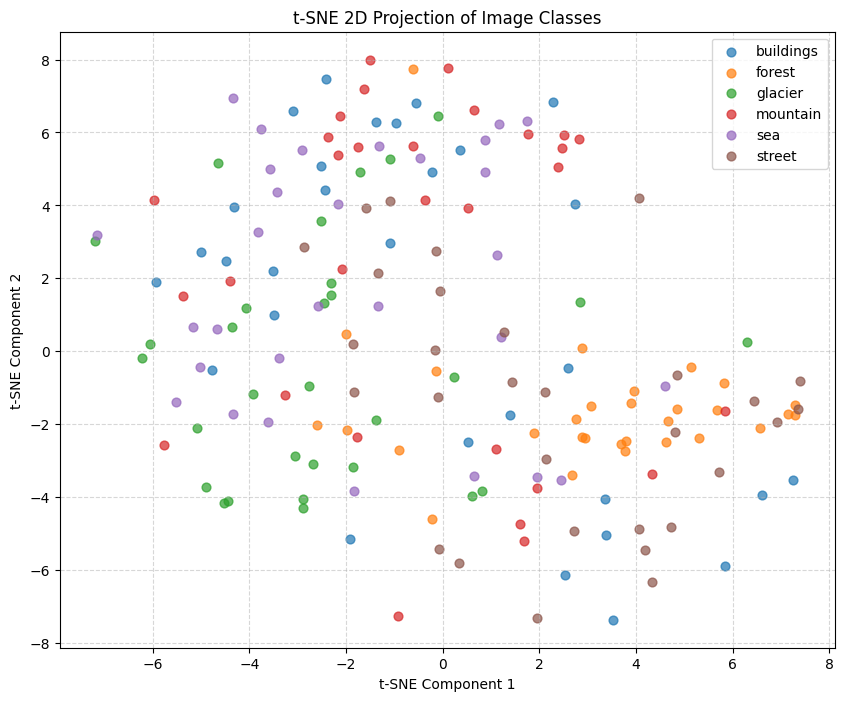

In [14]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

classes = sorted([
    folder for folder in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, folder))
])

sample_per_class = 30

image_features = []
labels = []

for class_name in classes:
    class_dir = os.path.join(train_dir, class_name)
    image_files = os.listdir(class_dir)
    sample_size = min(sample_per_class, len(image_files))
    sampled_images = random.sample(image_files, sample_size)
    for file_name in sampled_images:
        try:
            img_path = os.path.join(class_dir, file_name)
            img = Image.open(img_path).convert("L")
            img = img.resize((64, 64))
            img_array = np.array(img)
            image_features.append(img_array.flatten())
            labels.append(class_name)

        except Exception as e:
            print(f"Error processing {img_path}: {e}")

image_features = np.array(image_features)
labels = np.array(labels)
print(f"Shape before PCA/t-SNE: {image_features.shape}")

pca = PCA(
    n_components=50,
    random_state=42
)

pca_result = pca.fit_transform(image_features)

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

tsne_result = tsne.fit_transform(pca_result)

plt.figure(figsize=(10, 8))

for class_name in classes:
    idx = labels == class_name

    plt.scatter(
        tsne_result[idx, 0],
        tsne_result[idx, 1],
        label=class_name,
        alpha=0.7,
        s=40
    )

plt.title("t-SNE 2D Projection of Image Classes")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Analisis
Kelas forest terlihat cukup terkonsentrasi di area kanan bawah, hal ini mengindikasikan bahwa gambar forest memiliki feature yang cukup khas dan mudah dipelajari oleh CNN. Kelas glacier cenderung terkumpul di sisi kiri bawah dan kiri tengah. Distribusi ini menunjukkan adanya kemiripan visual antar gambar glacier, terutama dari tekstur dan dominasi warna terang. Kelas mountain, buildings, dan sea terlihat cukup tersebar dan saling overlap. Hal ini menandakan bahwa beberapa gambar dari kelas tersebut memiliki feature visual yang mirip. Kelas street juga menunjukkan overlap dengan beberapa kelas lain, terutama buildings. Kondisi ini masuk akal karena kedua kelas sama-sama mengandung elemen perkotaan.

Secara keseluruhan, meskipun terdapat overlap antar kelas, tetap terlihat adanya kecenderungan pembentukan cluster berdasarkan kategori gambar. Ini menunjukkan bahwa dataset memiliki feature visual yang cukup informatif untuk dipelajari oleh model CNN.

## Model

In [15]:
def build_cnn_model(num_conv_layers=2, filters_list=[32, 64], kernel_size=(3,3), pooling_type='max'):
    model = models.Sequential()

    # preprocessing
    model.add(layers.InputLayer(input_shape=(150, 150, 3)))
    model.add(layers.Rescaling(1./255))

    for i in range(num_conv_layers):
        model.add(layers.Conv2D(filters=filters_list[i],
                                kernel_size=kernel_size,
                                activation='relu',
                                padding='same'))

        if pooling_type == 'max':
            model.add(layers.MaxPooling2D(pool_size=(2, 2)))
        elif pooling_type == 'avg':
            model.add(layers.AveragePooling2D(pool_size=(2, 2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(6, activation='softmax')) 

    return model

## Train and Evaluate

In [ ]:
def train_and_evaluate(model_name, model, epochs=10):
    print(f"\n" + "="*40)
    print(f" MULAI TRAINING: {model_name}")
    print("="*40)

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(train_ds, validation_data=test_ds, epochs=epochs)

    # hitung F1-Score
    print("\nMenghitung Macro F1-Score...")
    y_pred_probs = model.predict(test_ds)
    y_pred = np.argmax(y_pred_probs, axis=1)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    print(f"MACRO F1-SCORE: {macro_f1:.4f}")

    # simpan Bobot
    save_path = f"{model_name}.weights.h5"
    model.save_weights(save_path)
    print(f"Bobot disimpan di: {save_path}")

    # grafik loss & accuracy
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # accuracy
    axes[0].plot(history.history['accuracy'], label='Train Acc')
    axes[0].plot(history.history['val_accuracy'], label='Val Acc')
    axes[0].set_title(f'Accuracy - {model_name}')
    axes[0].legend()

    # loss
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'Loss - {model_name}')
    axes[1].legend()

    plt.show()

    return history, macro_f1

# menyimpan skor akhir untuk perbandingan
hasil_eksperimen = {}

## Kombinasi 16 Arsitektur

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(



 MULAI TRAINING: Kombinasi_1
Epoch 1/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 23s 40ms/step - accuracy: 0.6292 - loss: 1.0102 - val_accuracy: 0.7260 - val_loss: 0.7338
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.7809 - loss: 0.5977 - val_accuracy: 0.7683 - val_loss: 0.6516
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.8571 - loss: 0.3979 - val_accuracy: 0.7637 - val_loss: 0.7248
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.9250 - loss: 0.2193 - val_accuracy: 0.7843 - val_loss: 0.7431
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.9637 - loss: 0.1150 - val_accuracy: 0.7813 - val_loss: 0.9359
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.9810 - loss: 0.0711 - val_accuracy: 0.7853 - val_loss: 1.0862
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.9853 - loss: 0.0510 - val_accuracy: 0.7850 - val_loss: 1.1226
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accu

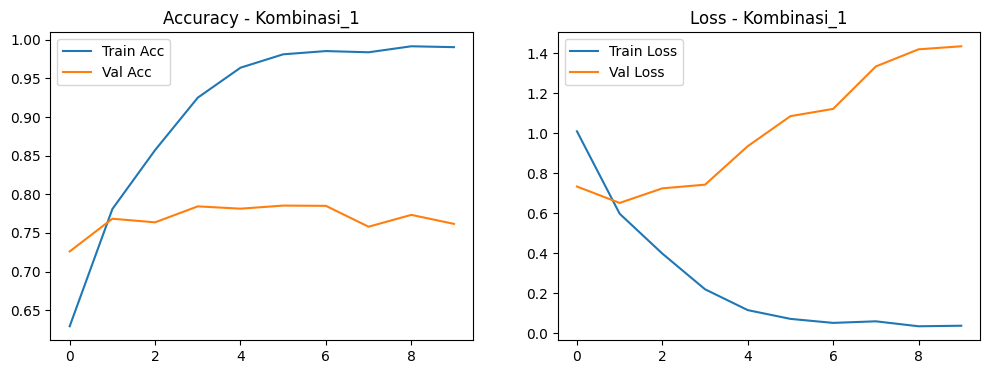

In [5]:
# Kombinasi 1 : 2 Layer, Filter 32->64, Kernel 3x3, Max Pooling
model_1 = build_cnn_model(num_conv_layers=2, filters_list=[32, 64], kernel_size=(3,3), pooling_type='max')
_, f1_1 = train_and_evaluate("Kombinasi_1", model_1, epochs=10)
hasil_eksperimen["Kombinasi_1"] = f1_1


 MULAI TRAINING: Kombinasi_2
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


439/439 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.6238 - loss: 1.0249 - val_accuracy: 0.6917 - val_loss: 0.8223
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.7390 - loss: 0.7030 - val_accuracy: 0.7433 - val_loss: 0.7072
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.8152 - loss: 0.5229 - val_accuracy: 0.7460 - val_loss: 0.7028
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.8822 - loss: 0.3474 - val_accuracy: 0.7767 - val_loss: 0.6884
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9287 - loss: 0.2140 - val_accuracy: 0.7480 - val_loss: 0.8546
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9563 - loss: 0.1341 - val_accuracy: 0.7527 - val_loss: 1.0440
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.9719 - loss: 0.0905 - val_accuracy: 0.7483 - val_loss: 1.1809
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9751 - loss: 0.0865 - val_accurac

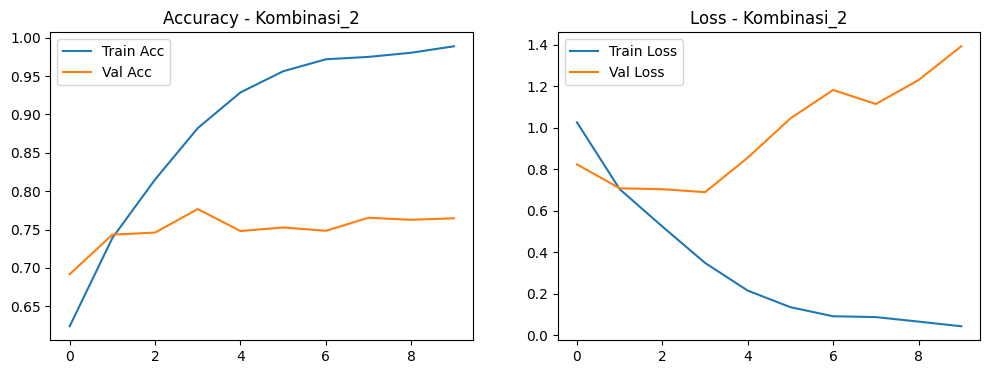

In [6]:
# Kombinasi 2 : 2 Layer, Filter 32->64, Kernel 3x3, Avg Pooling
model_2 = build_cnn_model(num_conv_layers=2, filters_list=[32, 64], kernel_size=(3,3), pooling_type='avg')
_, f1_2 = train_and_evaluate("Kombinasi_2", model_2, epochs=10)
hasil_eksperimen["Kombinasi_2"] = f1_2


 MULAI TRAINING: Kombinasi_3
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


439/439 ━━━━━━━━━━━━━━━━━━━━ 25s 43ms/step - accuracy: 0.6427 - loss: 0.9318 - val_accuracy: 0.7043 - val_loss: 0.8012
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.7713 - loss: 0.6199 - val_accuracy: 0.7563 - val_loss: 0.6866
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.8394 - loss: 0.4465 - val_accuracy: 0.7867 - val_loss: 0.6146
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.8991 - loss: 0.2815 - val_accuracy: 0.7490 - val_loss: 0.8029
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.9472 - loss: 0.1647 - val_accuracy: 0.7687 - val_loss: 0.8185
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.9671 - loss: 0.1139 - val_accuracy: 0.7520 - val_loss: 1.1369
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.9770 - loss: 0.0787 - val_accuracy: 0.7673 - val_loss: 1.2662
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.9785 - loss: 0.0670 - val_accurac

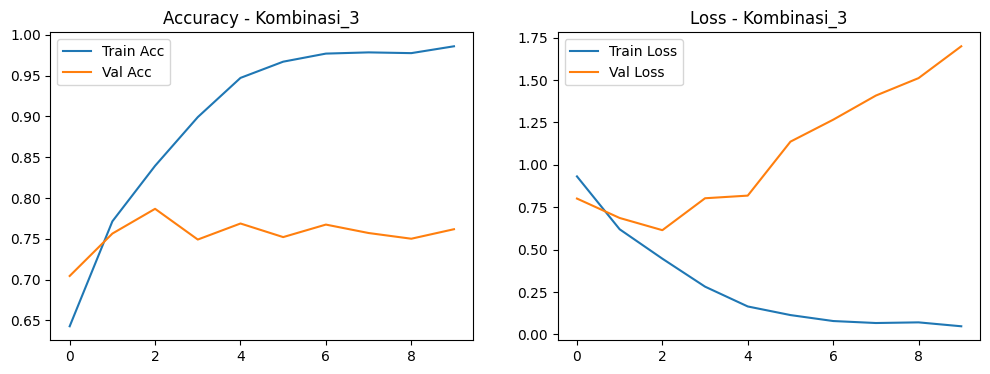

In [7]:
# Kombinasi 3 : 2 Layer, Filter 32->64, Kernel 5x5, Max Pooling
model_3 = build_cnn_model(num_conv_layers=2, filters_list=[32, 64], kernel_size=(5,5), pooling_type='max')
_, f1_3 = train_and_evaluate("Kombinasi_3", model_3, epochs=10)
hasil_eksperimen["Kombinasi_3"] = f1_3


 MULAI TRAINING: Kombinasi_4
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


439/439 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.5902 - loss: 1.0785 - val_accuracy: 0.6687 - val_loss: 0.8826
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.7067 - loss: 0.7960 - val_accuracy: 0.7293 - val_loss: 0.7386
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.7857 - loss: 0.6094 - val_accuracy: 0.7303 - val_loss: 0.7284
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8267 - loss: 0.4790 - val_accuracy: 0.7617 - val_loss: 0.6746
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.8858 - loss: 0.3324 - val_accuracy: 0.7653 - val_loss: 0.7394
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.9213 - loss: 0.2220 - val_accuracy: 0.7547 - val_loss: 0.9180
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9453 - loss: 0.1612 - val_accuracy: 0.7650 - val_loss: 1.0284
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9616 - loss: 0.1181 - val_accurac

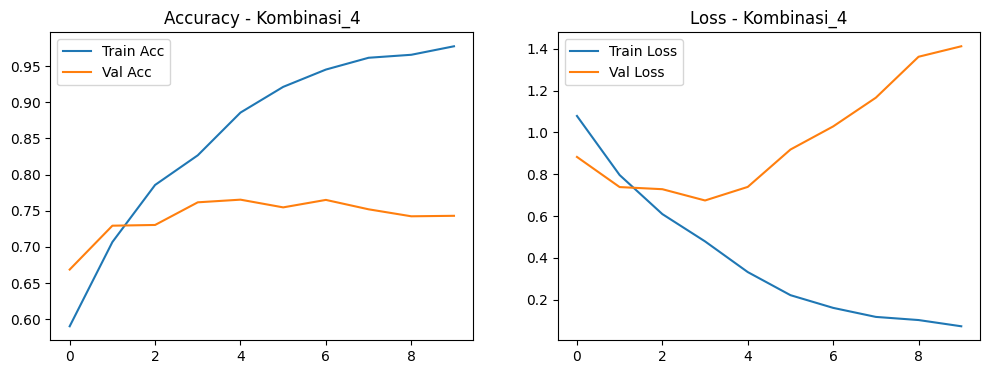

In [8]:
# Kombinasi 4 : 2 Layer, Filter 32->64, Kernel 5x5, Avg Pooling
model_4 = build_cnn_model(num_conv_layers=2, filters_list=[32, 64], kernel_size=(5,5), pooling_type='avg')
_, f1_4 = train_and_evaluate("Kombinasi_4", model_4, epochs=10)
hasil_eksperimen["Kombinasi_4"] = f1_4

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(



 MULAI TRAINING: Kombinasi_5
Epoch 1/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 35s 63ms/step - accuracy: 0.6298 - loss: 1.0220 - val_accuracy: 0.7100 - val_loss: 0.7777
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.7718 - loss: 0.6230 - val_accuracy: 0.7487 - val_loss: 0.6973
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.8459 - loss: 0.4285 - val_accuracy: 0.7433 - val_loss: 0.7839
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.9162 - loss: 0.2449 - val_accuracy: 0.7667 - val_loss: 0.8269
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.9571 - loss: 0.1378 - val_accuracy: 0.7587 - val_loss: 0.9791
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.9783 - loss: 0.0795 - val_accuracy: 0.7787 - val_loss: 1.0870
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - accuracy: 0.9848 - loss: 0.0582 - val_accuracy: 0.7743 - val_loss: 1.2247
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accu

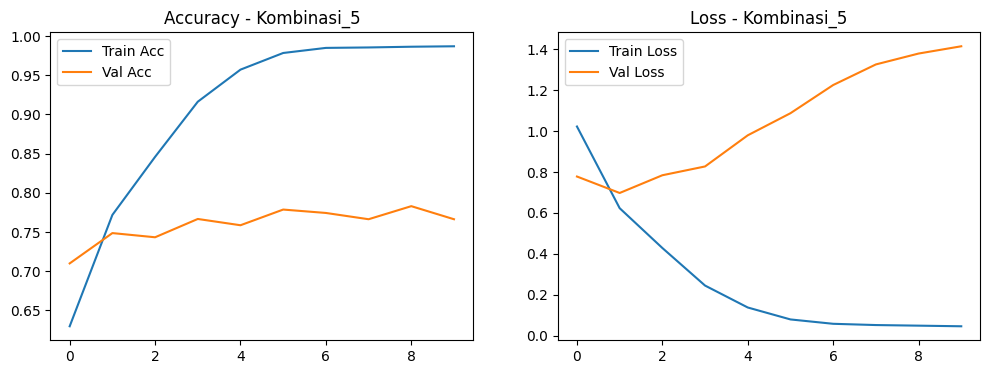

In [9]:
# Kombinasi 5 : 2 Layer, Filter 64->128, Kernel 3x3, Max Pooling
model_5 = build_cnn_model(num_conv_layers=2, filters_list=[64, 128], kernel_size=(3,3), pooling_type='max')
_, f1_5 = train_and_evaluate("Kombinasi_5", model_5, epochs=10)
hasil_eksperimen["Kombinasi_5"] = f1_5


 MULAI TRAINING: Kombinasi_6
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


439/439 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.6279 - loss: 0.9897 - val_accuracy: 0.7003 - val_loss: 0.8052
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.7608 - loss: 0.6581 - val_accuracy: 0.7500 - val_loss: 0.6781
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 22s 40ms/step - accuracy: 0.8299 - loss: 0.4737 - val_accuracy: 0.7640 - val_loss: 0.6770
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.8865 - loss: 0.3156 - val_accuracy: 0.7663 - val_loss: 0.7660
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9365 - loss: 0.1881 - val_accuracy: 0.7627 - val_loss: 0.8852
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.9559 - loss: 0.1380 - val_accuracy: 0.7433 - val_loss: 1.0488
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 21s 37ms/step - accuracy: 0.9669 - loss: 0.1060 - val_accuracy: 0.7587 - val_loss: 1.1870
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9778 - loss: 0.0765 - val_accurac

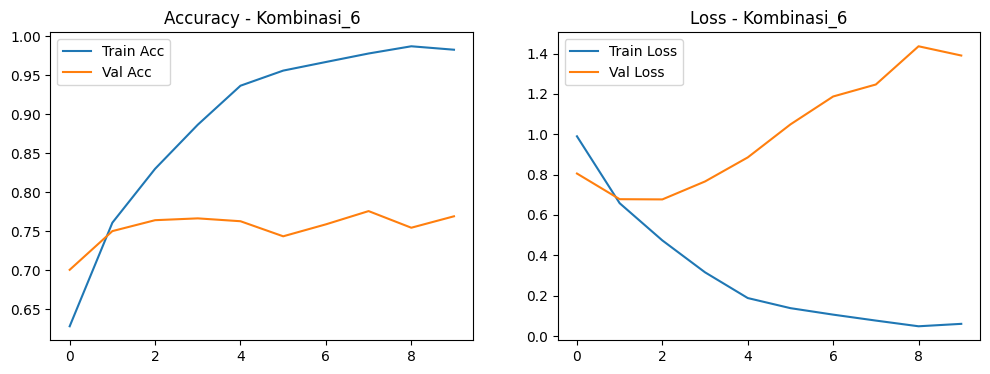

In [10]:
# Kombinasi 6 : 2 Layer, Filter 64->128, Kernel 3x3, Avg Pooling
model_6 = build_cnn_model(num_conv_layers=2, filters_list=[64, 128], kernel_size=(3,3), pooling_type='avg')
_, f1_6 = train_and_evaluate("Kombinasi_6", model_6, epochs=10)
hasil_eksperimen["Kombinasi_6"] = f1_6


 MULAI TRAINING: Kombinasi_7
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


439/439 ━━━━━━━━━━━━━━━━━━━━ 48s 91ms/step - accuracy: 0.5822 - loss: 1.1292 - val_accuracy: 0.6557 - val_loss: 0.9128
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 28s 64ms/step - accuracy: 0.7056 - loss: 0.7825 - val_accuracy: 0.6703 - val_loss: 0.8792
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.7674 - loss: 0.6180 - val_accuracy: 0.7550 - val_loss: 0.6904
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 29s 66ms/step - accuracy: 0.8380 - loss: 0.4431 - val_accuracy: 0.7490 - val_loss: 0.7479
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 29s 65ms/step - accuracy: 0.8828 - loss: 0.3319 - val_accuracy: 0.7447 - val_loss: 0.8330
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 29s 65ms/step - accuracy: 0.9270 - loss: 0.2152 - val_accuracy: 0.7410 - val_loss: 1.0138
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 29s 65ms/step - accuracy: 0.9415 - loss: 0.1697 - val_accuracy: 0.7450 - val_loss: 1.1703
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.9643 - loss: 0.1094 - val_accurac

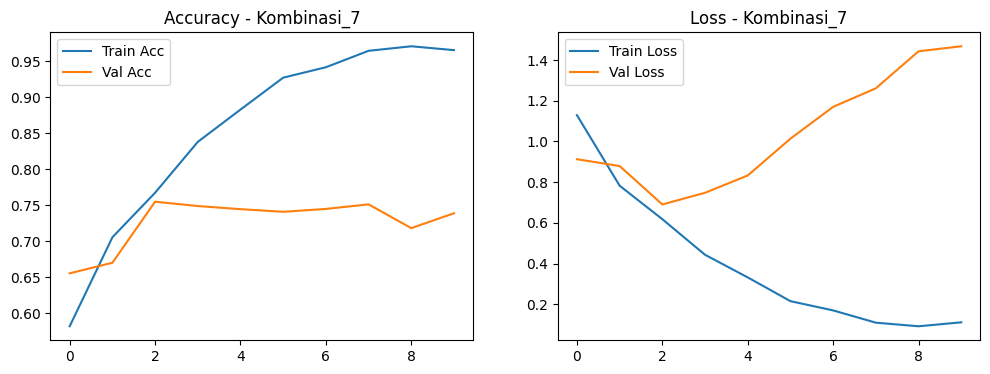

In [11]:
# Kombinasi 7 : 2 Layer, Filter 64->128, Kernel 5x5, Max Pooling
model_7 = build_cnn_model(num_conv_layers=2, filters_list=[64, 128], kernel_size=(5,5), pooling_type='max')
_, f1_7 = train_and_evaluate("Kombinasi_7", model_7, epochs=10)
hasil_eksperimen["Kombinasi_7"] = f1_7


 MULAI TRAINING: Kombinasi_8
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


439/439 ━━━━━━━━━━━━━━━━━━━━ 29s 61ms/step - accuracy: 0.5775 - loss: 1.1252 - val_accuracy: 0.6737 - val_loss: 0.8476
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 24s 55ms/step - accuracy: 0.7022 - loss: 0.7801 - val_accuracy: 0.7050 - val_loss: 0.7872
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 23s 52ms/step - accuracy: 0.7692 - loss: 0.6271 - val_accuracy: 0.7247 - val_loss: 0.7366
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 43s 56ms/step - accuracy: 0.8246 - loss: 0.4802 - val_accuracy: 0.7110 - val_loss: 0.8513
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 25s 57ms/step - accuracy: 0.8859 - loss: 0.3217 - val_accuracy: 0.7100 - val_loss: 0.9328
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 23s 52ms/step - accuracy: 0.9245 - loss: 0.2172 - val_accuracy: 0.7337 - val_loss: 1.0727
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.9602 - loss: 0.1269 - val_accuracy: 0.7500 - val_loss: 1.2696
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.9742 - loss: 0.0874 - val_accurac

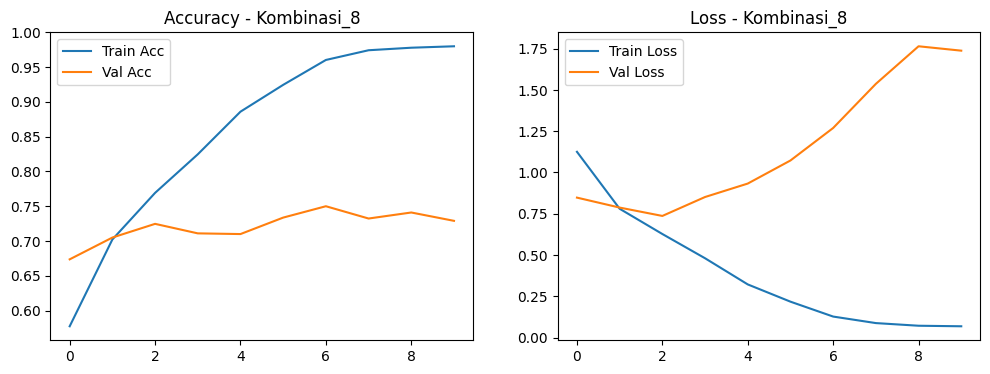

In [12]:
# Kombinasi 8 : 2 Layer, Filter 64->128, Kernel 5x5, Avg Pooling
model_8 = build_cnn_model(num_conv_layers=2, filters_list=[64, 128], kernel_size=(5,5), pooling_type='avg')
_, f1_8 = train_and_evaluate("Kombinasi_8", model_8, epochs=10)
hasil_eksperimen["Kombinasi_8"] = f1_8


 MULAI TRAINING: Kombinasi_9
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


439/439 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.6213 - loss: 0.9711 - val_accuracy: 0.7020 - val_loss: 0.7818
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.7805 - loss: 0.6012 - val_accuracy: 0.7930 - val_loss: 0.5904
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.8316 - loss: 0.4613 - val_accuracy: 0.7890 - val_loss: 0.5953
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.8706 - loss: 0.3537 - val_accuracy: 0.8103 - val_loss: 0.5744
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.9056 - loss: 0.2648 - val_accuracy: 0.7997 - val_loss: 0.6604
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.9369 - loss: 0.1858 - val_accuracy: 0.8000 - val_loss: 0.7319
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.9573 - loss: 0.1232 - val_accuracy: 0.7830 - val_loss: 0.9567
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.9644 - loss: 0.1103 - val_accurac

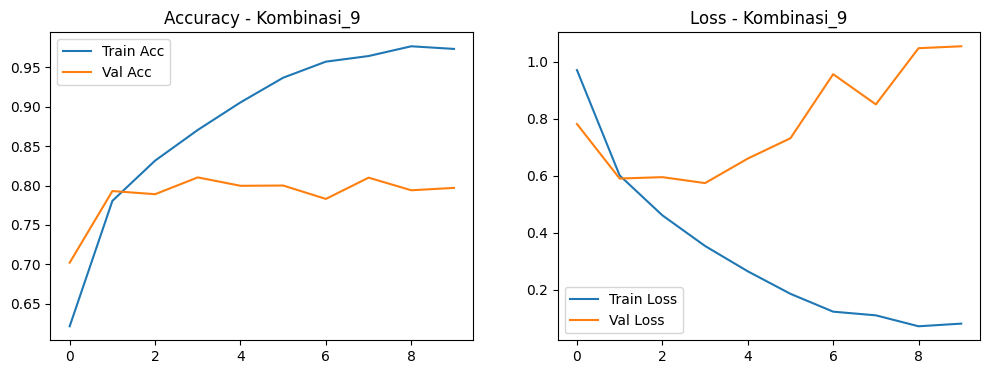

In [13]:
# Kombinasi 9 :  3 Layer, Filter 32->64->128, Kernel 3x3, Max Pooling
model_9 = build_cnn_model(num_conv_layers=3, filters_list=[32, 64, 128], kernel_size=(3,3), pooling_type='max')
_, f1_9 = train_and_evaluate("Kombinasi_9", model_9, epochs=10)
hasil_eksperimen["Kombinasi_9"] = f1_9


 MULAI TRAINING: Kombinasi_10
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


439/439 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.6308 - loss: 0.9767 - val_accuracy: 0.7423 - val_loss: 0.7060
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.7560 - loss: 0.6611 - val_accuracy: 0.7550 - val_loss: 0.6639
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8126 - loss: 0.5157 - val_accuracy: 0.7963 - val_loss: 0.5591
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.8524 - loss: 0.4100 - val_accuracy: 0.7887 - val_loss: 0.5893
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.8897 - loss: 0.3098 - val_accuracy: 0.7997 - val_loss: 0.6025
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9188 - loss: 0.2255 - val_accuracy: 0.7933 - val_loss: 0.7284
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9403 - loss: 0.1748 - val_accuracy: 0.7987 - val_loss: 0.8090
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9589 - loss: 0.1267 - val_accurac

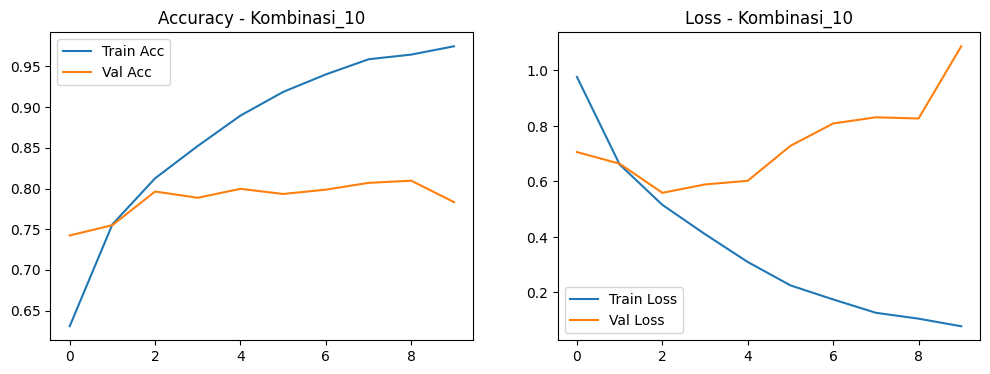

In [14]:
# Kombinasi 10 :  3 Layer, Filter 32->64->128, Kernel 3x3, Avg Pooling
model_10 = build_cnn_model(num_conv_layers=3, filters_list=[32, 64, 128], kernel_size=(3,3), pooling_type='avg')
_, f1_10 = train_and_evaluate("Kombinasi_10", model_10, epochs=10)
hasil_eksperimen["Kombinasi_10"] = f1_10


 MULAI TRAINING: Kombinasi_11
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


439/439 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step - accuracy: 0.6169 - loss: 0.9888 - val_accuracy: 0.7383 - val_loss: 0.7303
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.7657 - loss: 0.6455 - val_accuracy: 0.7860 - val_loss: 0.5986
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.8148 - loss: 0.5153 - val_accuracy: 0.7710 - val_loss: 0.6213
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.8583 - loss: 0.3974 - val_accuracy: 0.8050 - val_loss: 0.5562
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.8972 - loss: 0.2924 - val_accuracy: 0.7967 - val_loss: 0.6247
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.9270 - loss: 0.2107 - val_accuracy: 0.8073 - val_loss: 0.7160
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.9518 - loss: 0.1459 - val_accuracy: 0.8007 - val_loss: 0.9165
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.9644 - loss: 0.1082 - val_accurac

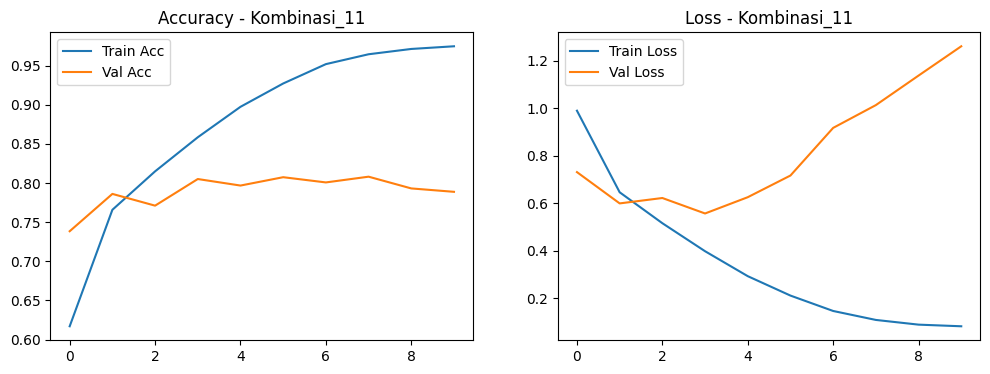

In [15]:
# Kombinasi 11 :  3 Layer, Filter 32->64->128, Kernel 5x5, Max Pooling
model_11 = build_cnn_model(num_conv_layers=3, filters_list=[32, 64, 128], kernel_size=(5,5), pooling_type='max')
_, f1_11 = train_and_evaluate("Kombinasi_11", model_11, epochs=10)
hasil_eksperimen["Kombinasi_11"] = f1_11


 MULAI TRAINING: Kombinasi_12
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


439/439 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.5972 - loss: 1.0304 - val_accuracy: 0.6907 - val_loss: 0.8250
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.7175 - loss: 0.7511 - val_accuracy: 0.7423 - val_loss: 0.6929
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.7767 - loss: 0.6070 - val_accuracy: 0.7867 - val_loss: 0.5739
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.8204 - loss: 0.4941 - val_accuracy: 0.7903 - val_loss: 0.5757
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.8532 - loss: 0.3998 - val_accuracy: 0.7850 - val_loss: 0.5994
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.8909 - loss: 0.3125 - val_accuracy: 0.7853 - val_loss: 0.6414
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.9173 - loss: 0.2344 - val_accuracy: 0.7653 - val_loss: 0.8381
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.9370 - loss: 0.1882 - val_accurac

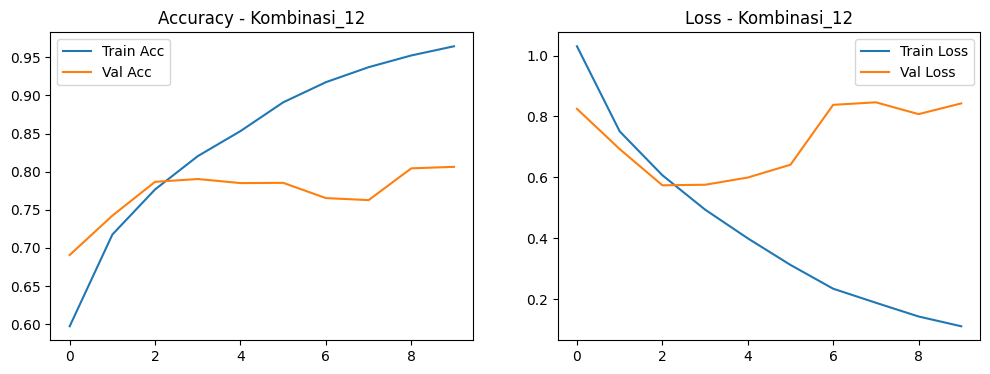

In [16]:
# Kombinasi 12 :  3 Layer, Filter 32->64->128, Kernel 5x5, Avg Pooling
model_12 = build_cnn_model(num_conv_layers=3, filters_list=[32, 64, 128], kernel_size=(5,5), pooling_type='avg')
_, f1_12 = train_and_evaluate("Kombinasi_12", model_12, epochs=10)
hasil_eksperimen["Kombinasi_12"] = f1_12


 MULAI TRAINING: Kombinasi_13
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


439/439 ━━━━━━━━━━━━━━━━━━━━ 40s 79ms/step - accuracy: 0.6280 - loss: 0.9824 - val_accuracy: 0.7193 - val_loss: 0.7588
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 30s 64ms/step - accuracy: 0.7693 - loss: 0.6308 - val_accuracy: 0.7853 - val_loss: 0.6010
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 28s 64ms/step - accuracy: 0.8287 - loss: 0.4742 - val_accuracy: 0.8127 - val_loss: 0.5435
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 28s 64ms/step - accuracy: 0.8672 - loss: 0.3697 - val_accuracy: 0.8010 - val_loss: 0.5846
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 28s 64ms/step - accuracy: 0.9048 - loss: 0.2596 - val_accuracy: 0.8087 - val_loss: 0.6637
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 28s 64ms/step - accuracy: 0.9352 - loss: 0.1810 - val_accuracy: 0.7930 - val_loss: 0.7822
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 28s 64ms/step - accuracy: 0.9540 - loss: 0.1331 - val_accuracy: 0.7980 - val_loss: 0.8190
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 29s 66ms/step - accuracy: 0.9721 - loss: 0.0836 - val_accurac

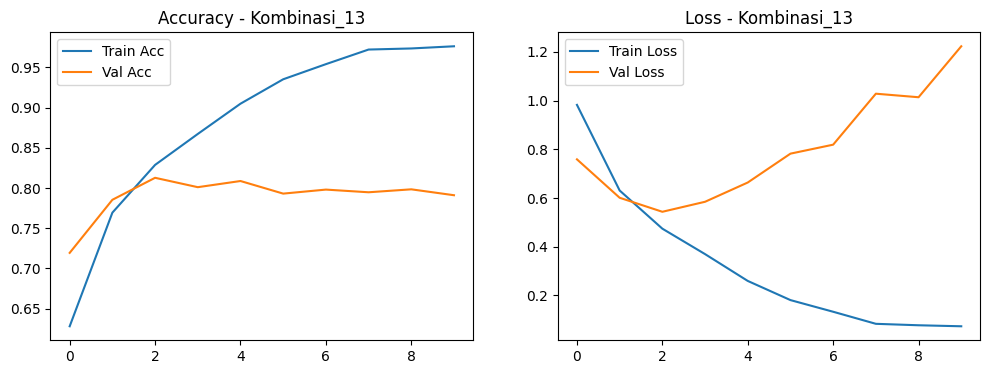

In [17]:
# Kombinasi 13 :  3 Layer, Filter 64->128->256, Kernel 3x3, Max Pooling
model_13 = build_cnn_model(num_conv_layers=3, filters_list=[64, 128, 256], kernel_size=(3,3), pooling_type='max')
_, f1_13 = train_and_evaluate("Kombinasi_13", model_13, epochs=10)
hasil_eksperimen["Kombinasi_13"] = f1_13


 MULAI TRAINING: Kombinasi_14
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


439/439 ━━━━━━━━━━━━━━━━━━━━ 27s 56ms/step - accuracy: 0.6132 - loss: 0.9887 - val_accuracy: 0.7250 - val_loss: 0.7432
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 37s 51ms/step - accuracy: 0.7479 - loss: 0.6798 - val_accuracy: 0.7710 - val_loss: 0.6192
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 23s 54ms/step - accuracy: 0.8077 - loss: 0.5254 - val_accuracy: 0.8007 - val_loss: 0.5562
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.8511 - loss: 0.4043 - val_accuracy: 0.8083 - val_loss: 0.5619
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.8925 - loss: 0.3018 - val_accuracy: 0.7980 - val_loss: 0.6312
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - accuracy: 0.9156 - loss: 0.2295 - val_accuracy: 0.8060 - val_loss: 0.7134
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - accuracy: 0.9432 - loss: 0.1646 - val_accuracy: 0.7977 - val_loss: 0.8380
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - accuracy: 0.9550 - loss: 0.1360 - val_accurac

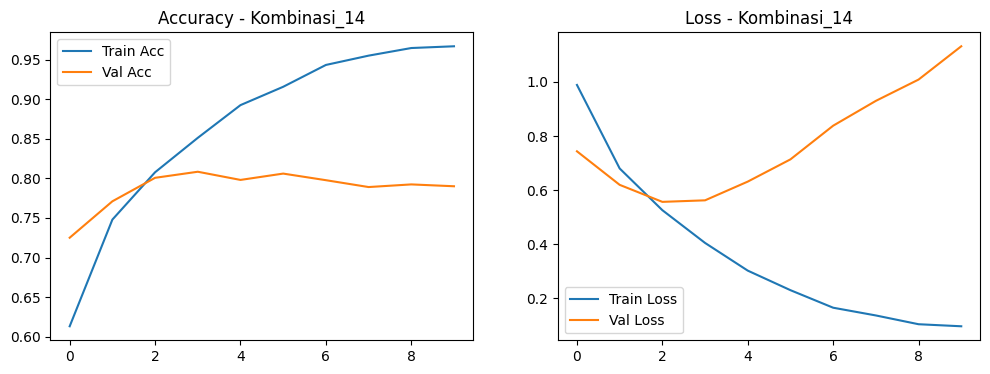

In [18]:
# Kombinasi 14 :  3 Layer, Filter 64->128->256, Kernel 3x3, Avg Pooling
model_14 = build_cnn_model(num_conv_layers=3, filters_list=[64, 128, 256], kernel_size=(3,3), pooling_type='avg')
_, f1_14 = train_and_evaluate("Kombinasi_14", model_14, epochs=10)
hasil_eksperimen["Kombinasi_14"] = f1_14


 MULAI TRAINING: Kombinasi_15
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


439/439 ━━━━━━━━━━━━━━━━━━━━ 55s 110ms/step - accuracy: 0.5878 - loss: 1.0767 - val_accuracy: 0.6683 - val_loss: 0.8598
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 38s 86ms/step - accuracy: 0.7354 - loss: 0.7118 - val_accuracy: 0.7547 - val_loss: 0.6538
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 39s 89ms/step - accuracy: 0.7987 - loss: 0.5466 - val_accuracy: 0.7897 - val_loss: 0.5785
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 38s 88ms/step - accuracy: 0.8488 - loss: 0.4141 - val_accuracy: 0.8047 - val_loss: 0.5999
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 39s 89ms/step - accuracy: 0.8912 - loss: 0.3038 - val_accuracy: 0.7963 - val_loss: 0.6716
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 39s 89ms/step - accuracy: 0.9323 - loss: 0.1928 - val_accuracy: 0.7867 - val_loss: 0.7864
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 39s 89ms/step - accuracy: 0.9527 - loss: 0.1392 - val_accuracy: 0.8067 - val_loss: 0.8438
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 39s 88ms/step - accuracy: 0.9682 - loss: 0.1020 - val_accura

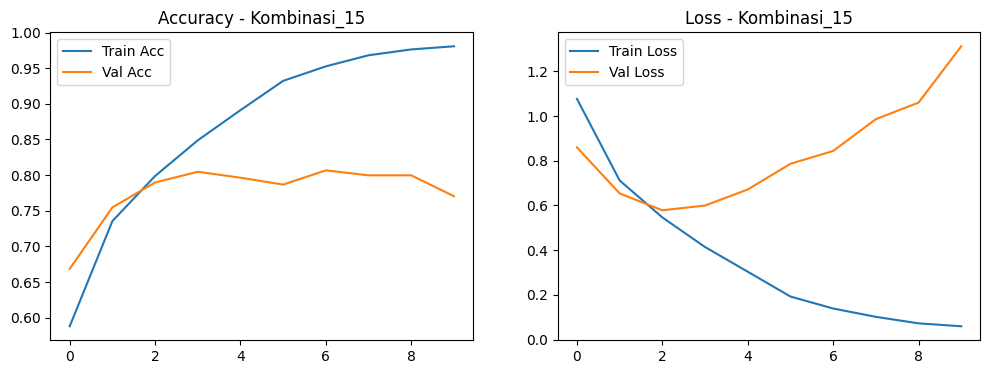

In [19]:
# Kombinasi 15 :  3 Layer, Filter 64->128->256, Kernel 5x5, Max Pooling
model_15 = build_cnn_model(num_conv_layers=3, filters_list=[64, 128, 256], kernel_size=(5,5), pooling_type='max')
_, f1_15 = train_and_evaluate("Kombinasi_15", model_15, epochs=10)
hasil_eksperimen["Kombinasi_15"] = f1_15

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(



 MULAI TRAINING: Kombinasi_16
Epoch 1/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 42s 87ms/step - accuracy: 0.5552 - loss: 1.1275 - val_accuracy: 0.6233 - val_loss: 0.9382
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 33s 75ms/step - accuracy: 0.6613 - loss: 0.8881 - val_accuracy: 0.7067 - val_loss: 0.7793
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 33s 76ms/step - accuracy: 0.7395 - loss: 0.6887 - val_accuracy: 0.7490 - val_loss: 0.6987
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 33s 75ms/step - accuracy: 0.8004 - loss: 0.5455 - val_accuracy: 0.7597 - val_loss: 0.6455
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 33s 75ms/step - accuracy: 0.8417 - loss: 0.4296 - val_accuracy: 0.7823 - val_loss: 0.6555
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 33s 75ms/step - accuracy: 0.8821 - loss: 0.3251 - val_accuracy: 0.7980 - val_loss: 0.6352
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 33s 76ms/step - accuracy: 0.9164 - loss: 0.2468 - val_accuracy: 0.7647 - val_loss: 0.8158
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 33s 76ms/step - acc

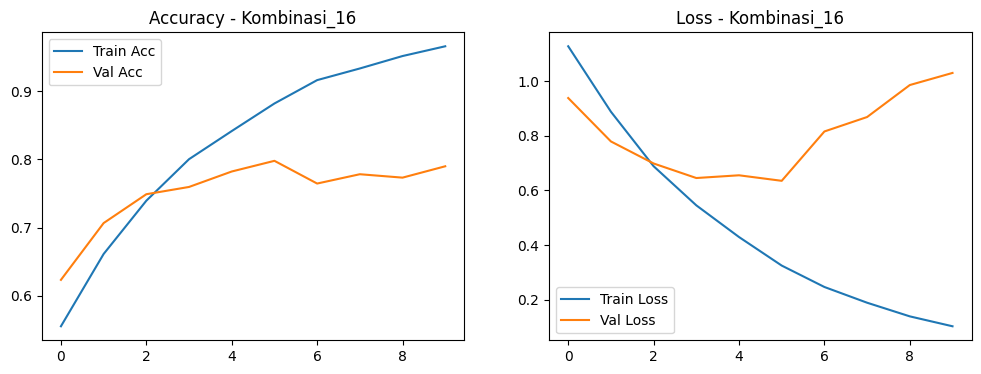

In [20]:
# Kombinasi 16 :  3 Layer, Filter 64->128->256, Kernel 5x5, Avg Pooling
model_16 = build_cnn_model(num_conv_layers=3, filters_list=[64, 128, 256], kernel_size=(5,5), pooling_type='avg')
_, f1_16 = train_and_evaluate("Kombinasi_16", model_16, epochs=10)
hasil_eksperimen["Kombinasi_16"] = f1_16

## Rekap Hasil Macro F1 Score

In [21]:
print("=== REKAP MACRO F1-SCORE ===")
for model_name, score in sorted(hasil_eksperimen.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name:20s}: {score:.4f}")

=== REKAP MACRO F1-SCORE ===
Kombinasi_12        : 0.8082
Kombinasi_9         : 0.7983
Kombinasi_13        : 0.7923
Kombinasi_11        : 0.7920
Kombinasi_16        : 0.7918
Kombinasi_14        : 0.7910
Kombinasi_10        : 0.7832
Kombinasi_15        : 0.7735
Kombinasi_6         : 0.7699
Kombinasi_5         : 0.7683
Kombinasi_2         : 0.7640
Kombinasi_1         : 0.7598
Kombinasi_3         : 0.7589
Kombinasi_4         : 0.7432
Kombinasi_7         : 0.7424
Kombinasi_8         : 0.7307


## Analisis
Berdasarkan eksperimen dengan 16 arsitektur yang berbeda dengan mengombinasikan jumlah layer, banyak filter, ukuran filter, dan jenis pooling, diperoleh bahwa arsitektur pada kombinasi 12 (3 layer, filter berukuran 32,64,128, dengan kernel berukuran 5x5, dan menggunakan max pooling) menghasilkan Macro F-1 score paling tinggi diantara kombinasi arsitektur yang lain. 

Hasil tersebut menunjukkan bahwa penambahan jumlah layer konvolusi cenderung meningkatkan kemampuan model dalam mengekstraksi fitur yang lebih kompleks. Hal ini terlihat karena sebagian besar kombinasi dengan 3 layer memperoleh skor yang lebih tinggi dibandingkan kombinasi dengan 2 layer.

Selain itu, penggunaan jumlah filter yang bertambah pada setiap layer membantu model menangkap fitur dengan tingkat abstraksi yang semakin tinggi. Filter yang lebih banyak pada layer akhir memungkinkan model mengenali pola yang lebih kompleks pada citra.

Kernel yang lebih besar mampu menangkap konteks spasial yang lebih luas sehingga fitur penting pada gambar dapat dikenali dengan lebih baik. Namun, pengaruh ukuran kernel tidak selalu konsisten pada seluruh kombinasi karena performa juga dipengaruhi oleh parameter lain seperti jumlah layer dan jenis pooling. Pada kasus ini, terjadi kecederungan kernel 3x3 memiliki performa yang lebih baik dibandingkan dengan kernel 5x5.

Pada jenis pooling, max pooling secara umum memberikan hasil lebih baik dibandingkan average pooling. Max pooling mempertahankan fitur paling dominan dari hasil konvolusi sehingga informasi penting pada citra tidak mudah hilang. Hal ini terlihat dari kombinasi terbaik yang menggunakan max pooling serta beberapa kombinasi dengan max pooling yang berada pada peringkat atas.

Sebaliknya, kombinasi dengan performa terendah adalah Kombinasi 8 dengan Macro F1-score sebesar 0.7307. Hal ini menunjukkan bahwa kombinasi hyperparameter tertentu dapat menyebabkan model kurang optimal dalam mempelajari pola data.

Secara keseluruhan, hasil eksperimen menunjukkan bahwa arsitektur CNN yang lebih dalam, menggunakan jumlah filter bertingkat, kernel yang lebih besar, dan max pooling cenderung memberikan performa klasifikasi yang lebih baik pada dataset yang digunakan.